# Import Libraries and Define Project Folders

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
DATA_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120  # optional, makes plots a bit sharper

# Load Data

In [3]:
df = pd.read_csv(
    DATA_DIR / "cbsd_main_2022_02.csv",
    dtype={"start_station_id": "string", "end_station_id": "string"},
    low_memory=False
)

# parse dates safely (errors='coerce' prevents crashes if any weird rows exist)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["ended_at"] = pd.to_datetime(df["ended_at"], errors="coerce")

df.shape

(29838166, 15)

In [4]:
daily = pd.read_csv(DATA_DIR / "cbsd_daily_2022_01.csv", parse_dates=["date"])
daily = daily.sort_values("date").set_index("date")

daily.shape

(365, 2)

In [5]:
daily.head()

,tavg_c,bike_rides_daily
date,,
2022-01-01,11.6,20428
2022-01-02,11.4,43009
2022-01-03,1.4,33189
2022-01-04,-2.7,36842
2022-01-05,3.2,34230


In [6]:
daily.columns

Index(['tavg_c', 'bike_rides_daily'], dtype='str')

# Set a Theme for all charts

In [7]:
sns.set_theme(style="whitegrid", palette="Blues")

In [8]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'tavg_c'],
      dtype='str')

In [14]:
# create a list of top 20 start stations
start_col = "start_station_name"

top20 = (
    df.dropna(subset=[start_col])
      .groupby(start_col)
      .size()
      .sort_values(ascending=False)
      .head(20)
      .reset_index(name="rides")
)

top20

,start_station_name,rides
0,W 21 St & 6 Ave,129016
1,West St & Chambers St,123289
2,Broadway & W 58 St,114293
3,6 Ave & W 33 St,106440
4,1 Ave & E 68 St,104856
5,Broadway & E 14 St,98862
6,Broadway & W 25 St,98422
7,University Pl & E 14 St,97120
8,Broadway & E 21 St,95691
9,W 31 St & 7 Ave,94208


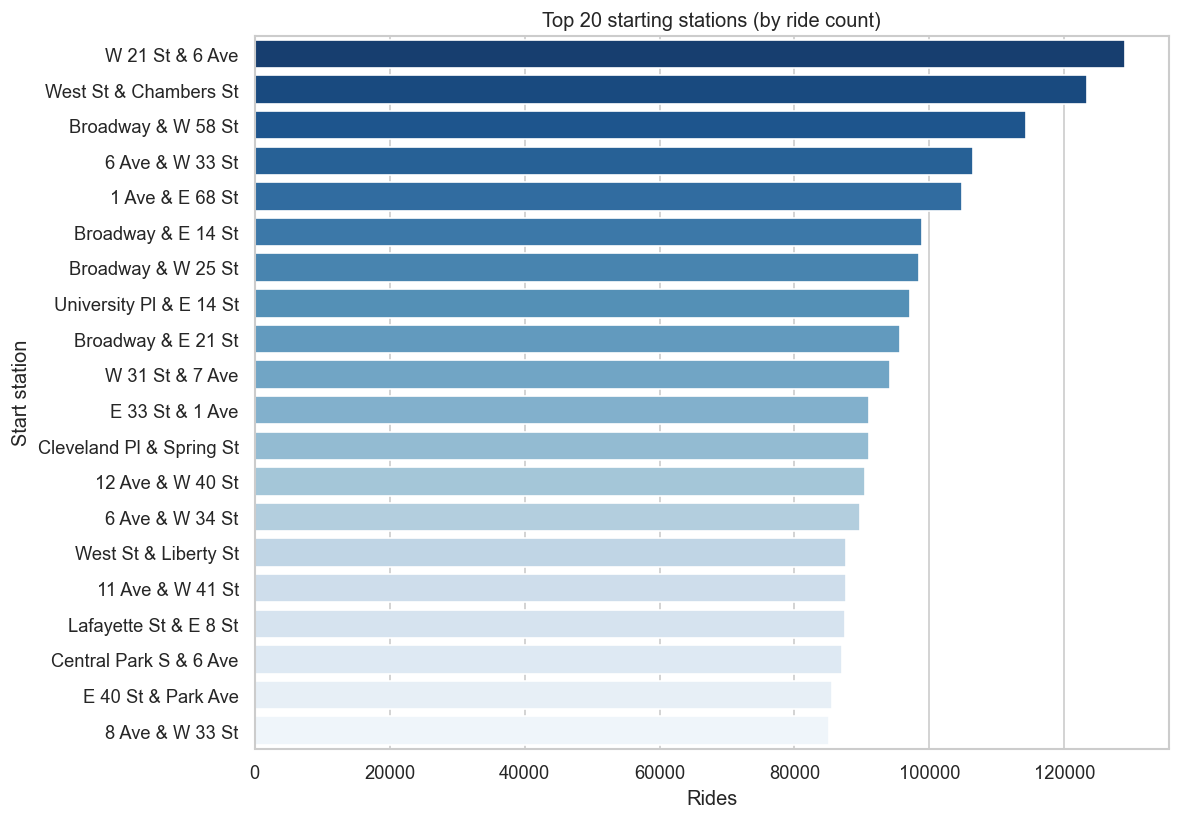

In [15]:
# check theme by plotting top 20 start stations
order = top20.sort_values("rides", ascending=False)["start_station_name"]
pal = sns.color_palette("Blues_r", n_colors=20)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top20,
    x="rides",
    y="start_station_name",
    order=order,
    hue="start_station_name",
    palette=pal,
    dodge=False
)

plt.legend([], [], frameon=False)  # remove the huge legend
plt.title("Top 20 starting stations (by ride count)")
plt.xlabel("Rides")
plt.ylabel("Start station")
plt.tight_layout()
plt.show()

# Comments
With my global theme palette, seaborn treated this as a single series and initially colored every bar the same. Since this plot has 20 categories, I temporarily forced a 20-shade sequential palette by mapping start_station_name to hue (and removing the legend) so the color intensity reflects ranking more clearly.

# Create a dual-axis line chart for daily rides and avg temperature in 2022

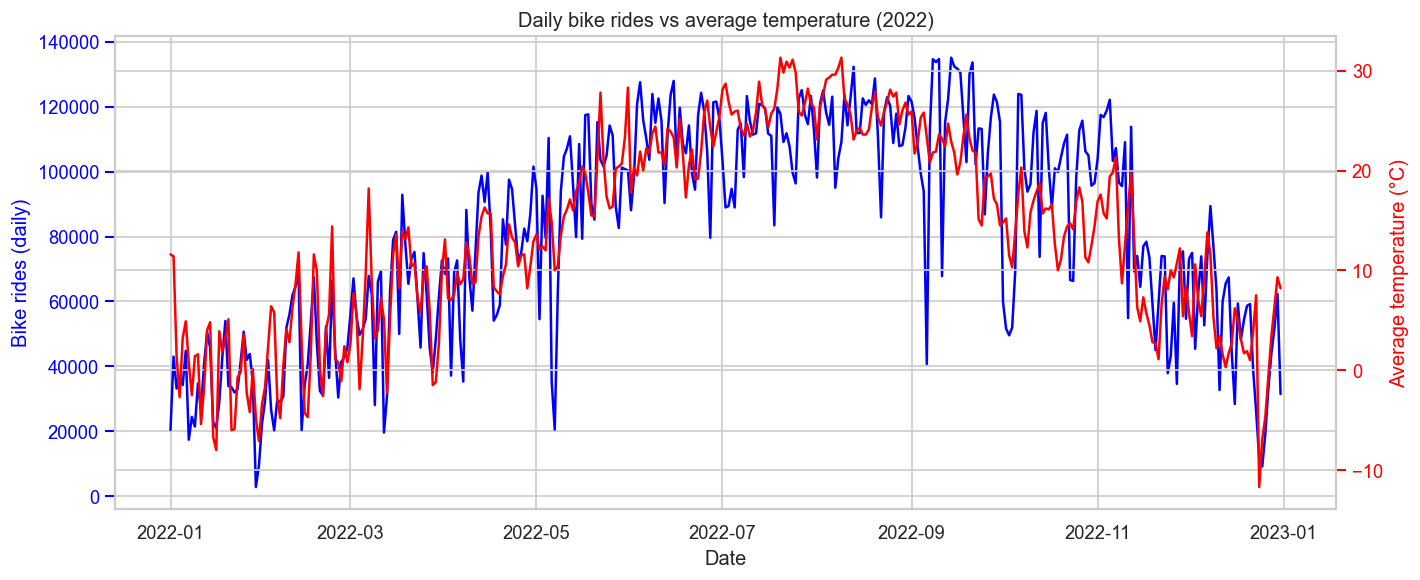

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

# Left axis: rides (blue)
sns.lineplot(
    data=daily,
    x=daily.index,
    y="bike_rides_daily",
    ax=ax,
    color="blue"
)
ax.set_xlabel("Date")
ax.set_ylabel("Bike rides (daily)", color="blue")
ax.tick_params(axis="y", colors="blue")

# Right axis: temperature (red)
ax2 = ax.twinx()
sns.lineplot(
    data=daily,
    x=daily.index,
    y="tavg_c",
    ax=ax2,
    color="red"
)
ax2.set_ylabel("Average temperature (°C)", color="red")
ax2.tick_params(axis="y", colors="red")

plt.title("Daily bike rides vs average temperature (2022)")
plt.tight_layout()
plt.show()

# Create a box plot using ride duration and member type

In [18]:
df_box = df.copy()

# find ride duration in minutes
df_box["ride_minutes"] = (df_box["ended_at"] - df_box["started_at"]).dt.total_seconds() / 60

# drop missing + remove weird negatives/zeros
df_box = df_box.dropna(subset=["ride_minutes", "member_casual"])
df_box = df_box[df_box["ride_minutes"] > 0]

df_box["ride_minutes"].describe()

count    2.983781e+07
mean     1.821030e+01
std      2.614500e+02
min      1.488333e-01
25%      5.796867e+00
50%      1.016213e+01
75%      1.799912e+01
max      4.044810e+05
Name: ride_minutes, dtype: float64

In [19]:
# Trim extreme outliers
p99 = df_box["ride_minutes"].quantile(0.99)
df_box_trim = df_box[df_box["ride_minutes"] <= p99]

p99

np.float64(82.8441846666659)

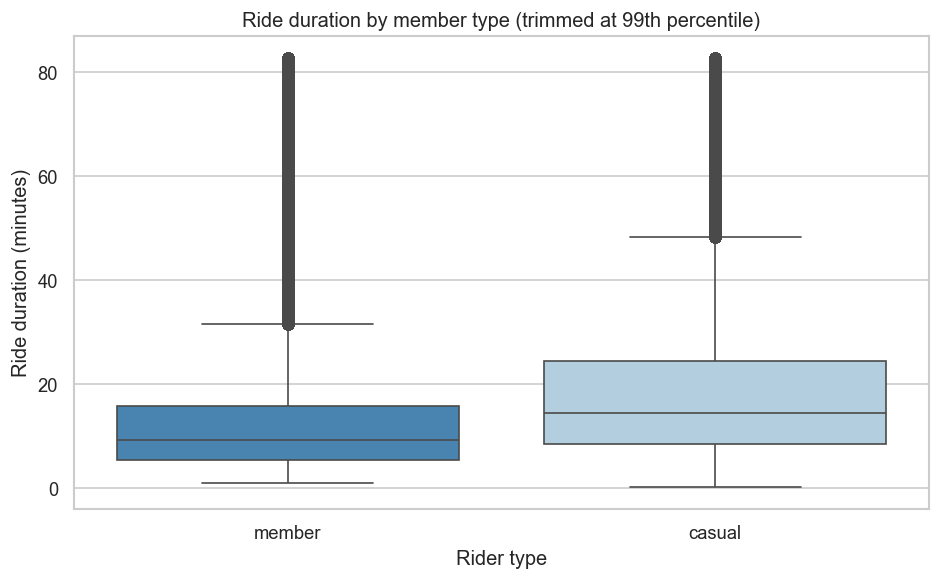

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_box_trim,
    x="member_casual",
    y="ride_minutes",
    hue="member_casual",     # <- add this
    palette="Blues_r",
    legend=False             # <- and this
)
plt.title("Ride duration by member type (trimmed at 99th percentile)")
plt.xlabel("Rider type")
plt.ylabel("Ride duration (minutes)")
plt.tight_layout()
plt.show()

# Comments on box plot results
The box plot shows that casual riders take longer trips on average than members. The median ride duration for casual riders is noticeably higher, and the casual group also has a wider interquartile range, which suggests more variability in typical trip lengths. Members have a lower median and a tighter box, meaning their rides are generally shorter and more consistent. Both groups still show many outliers (points above the whiskers), but the casual group’s upper whisker and outliers extend higher, indicating more frequent long rides even after trimming at the 99th percentile.

# Create a FacetGrid using ride duration

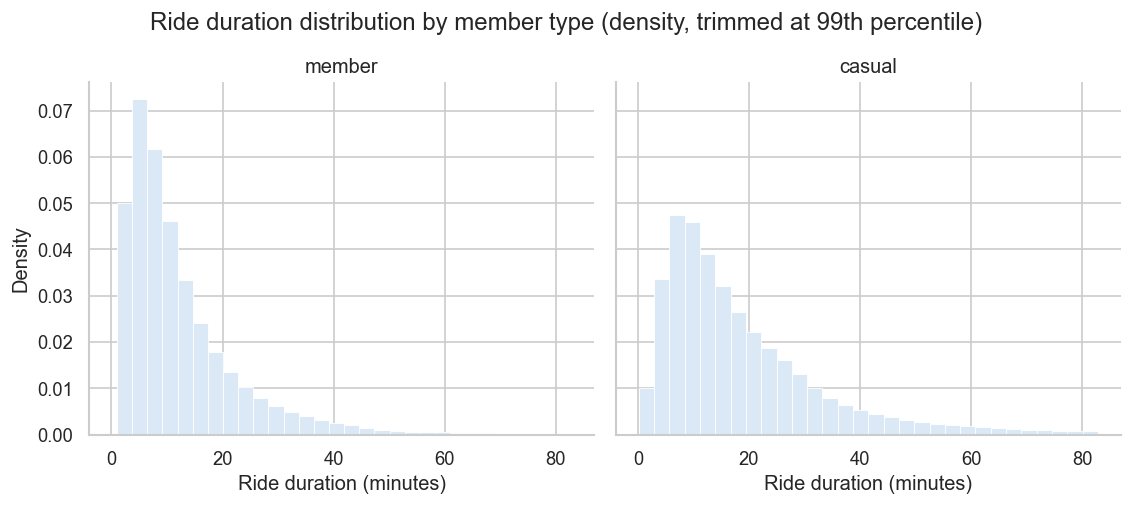

In [24]:
grid = sns.FacetGrid(df_box_trim, col="member_casual", height=4, aspect=1.2)
grid.map(sns.histplot, "ride_minutes", bins=30, stat="density", alpha=1, edgecolor="white", linewidth=0.5)
grid.set_axis_labels("Ride duration (minutes)", "Density")
grid.set_titles(col_template="{col_name}")
grid.fig.suptitle("Ride duration distribution by member type (density, trimmed at 99th percentile)", y=1.05)
plt.show()

# Comments on the FacetGrid
This FacetGrid compares the shape of ride-duration distributions for members vs casual riders using density, so differences aren’t driven by group size. Members are heavily concentrated in short rides (strong peak at low minutes) and taper off quickly, suggesting more routine, utilitarian trips. Casual riders have a flatter peak and a much heavier right tail, showing a higher proportion of longer rides, which supports the box plot’s higher median and wider spread for casual users. 